In [ ]:
import pandas as pd
import numpy as np
import copy as copy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

### loading dataset

In [5]:
data_set = pd.read_csv("SalaryData.csv")

### spilting the loaded data set into training data and testing data

In [6]:
# 30% data for testing and 70% for training,random state is 0 to get same results every time we run
x_train,x_test,y_train,y_test=train_test_split(data_set["YearsExperience"],data_set["Salary"],test_size=0.3,random_state=0)

### now x is for years of experience and y is for salary

In [7]:
print (y_train)
x_train


22    101302.0
5      56642.0
16     66029.0
8      64445.0
14     61111.0
23    113812.0
20     91738.0
1      46205.0
29    121872.0
6      60150.0
4      39891.0
18     81363.0
19     93940.0
9      57189.0
7      54445.0
25    105582.0
3      43525.0
0      39343.0
21     98273.0
15     67938.0
12     56957.0
Name: Salary, dtype: float64


22     7.9
5      2.9
16     5.1
8      3.2
14     4.5
23     8.2
20     6.8
1      1.3
29    10.5
6      3.0
4      2.2
18     5.9
19     6.0
9      3.7
7      3.2
25     9.0
3      2.0
0      1.1
21     7.1
15     4.9
12     4.0
Name: YearsExperience, dtype: float64

### formula for Linear Regression
y^ = b0 + b1*x

where:

b1 = ∑(xi - x')(yi - y') / ∑(xi - x')²

b0 = y' - b1*x'

# manual function of our model

In [8]:
def manual_linear_regression(x, y):

    # converting pandas series to numpy arrays and reshaping them to 1D arrays
    x = np.array(x).reshape(-1)
    y = np.array(y).reshape(-1)
  
    # Calculate means
    x_mean = np.mean(x) # x'
    y_mean = np.mean(y) # y'
    
    # Calculate b1
    b1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    
    # Calculate b0
    b0 = y_mean - (b1 * x_mean)
    
    return b0, b1


### Calculating b0 and b1

In [9]:
b0, b1 = manual_linear_regression(x_train, y_train)
# printing the calculated b0 and b1
b0 , b1

(np.float64(26777.39134119761), np.float64(9360.261286193658))

### function for prediction 

In [10]:
# Make predictions using the formula: y^ = b0 + b1*x
def predict(x, b0, b1):
    x = np.array(x).reshape(-1)
    return b0 + b1 * x

### prediction on test data (x_test)

In [11]:
y_hat = predict(x_test, b0, b1)
y_hat

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

### plotting

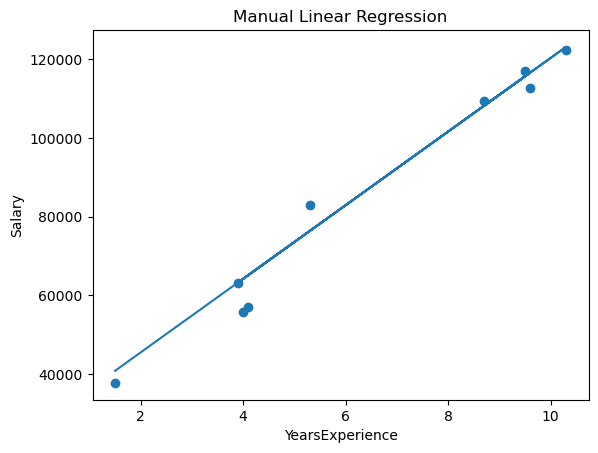

In [12]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_hat)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Manual Linear Regression")
plt.show()

# using sklearn library

In [13]:
# reshape the training data for sklearn, requires 2D input
x_train_sk = x_train.values.reshape(-1, 1)
x_test_sk = x_test.values.reshape(-1, 1)

model = LinearRegression()
model.fit(x_train_sk, y_train.values)

# make predictions on test data
y_hat_sklearn = model.predict(x_test_sk)
y_hat_sklearn

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

In [14]:

# get the b1 (weight/slope) and b0 (intercept/bias) from sklearn
b1_sklearn = model.coef_[0]   # weight/slope
b0_sklearn = model.intercept_ # bias/intercept
print(b1_sklearn)
print(b0_sklearn)

9360.261286193654
26777.391341197632


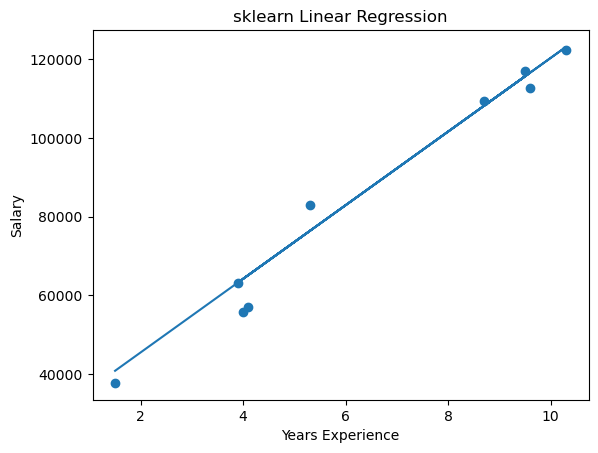

In [15]:
# plotting the sklearn predictions
plt.scatter(x_test, y_test)
plt.plot(x_test, y_hat_sklearn)
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.title('sklearn Linear Regression')
plt.show()

# evaluation metrics using formula

Mean Absolute Error (MAE): MAE = (1/n) * Σ |yi - y_pred_i|

R² Score: R² = 1 - ( Σ (yi - y_pred_i)² / Σ (yi - y_mean)² )

Root Mean Square Error (RMSE): RMSE = sqrt((1/n) * Σ (yi - y_pred_i)²)

In [16]:
# function to calculate Mean Absolute Error
def MAE(y_original, y_predicted):
    n = len(y_original)
    mean_abs_err = np.sum(np.abs(y_original - y_predicted)) / n
    return mean_abs_err

In [17]:
# function to calculate R² Score
def r2(y_true, y_pred):
    y_mean = np.mean(y_true)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_mean) ** 2))
    return r2

In [18]:
# function to calculate Root Mean Square Error
def RMSE(y_true, y_pred):
    n = len(y_true)
    rmse = np.sqrt(np.sum((y_true - y_pred) ** 2) / n)
    return rmse

In [19]:
# calculate evaluation metrics for manual implementation on test data
mae_manual = MAE(y_test.values, y_hat)
r2_manual = r2(y_test.values, y_hat)
rmse_manual = RMSE(y_test.values, y_hat)

print(f"MAE (Manual):  {mae_manual}")
print(f"R² Score (Manual): {r2_manual}")
print(f"RMSE (Manual): {rmse_manual}")

MAE (Manual):  3737.417861878893
R² Score (Manual): 0.9740993407213511
RMSE (Manual): 4834.260936361725


# evaluation metrics using sklearn

In [24]:
# calculate evaluation metrics for sklearn implementation on test data
mae_sklearn = metrics.mean_absolute_error(y_test.values, y_hat_sklearn)
r2_sklearn = metrics.r2_score(y_test.values, y_hat_sklearn)
rmse_sklearn = np.sqrt(metrics.mean_squared_error(y_test.values, y_hat_sklearn))

print(f"MAE (sklearn):  {mae_sklearn}")
print(f"R² Score (sklearn): {r2_sklearn}")
print(f"RMSE (sklearn): {rmse_sklearn}")

MAE (sklearn):  3737.4178618788987
R² Score (sklearn): 0.9740993407213511
RMSE (sklearn): 4834.260936361728
